### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


### Load Data

In [2]:
train = pd.read_csv('/content/data_training (1).csv')
test = pd.read_csv('/content/data_testing (1).csv')

### Ringkasan Data

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


Dari ringkasan tersebut, terlihat jelas bahwa tidak ada nilai kosong pada data

### Visualisasi Kualitas Wine

/tmp/ipykernel_11880/923797838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=train, palette='viridis')


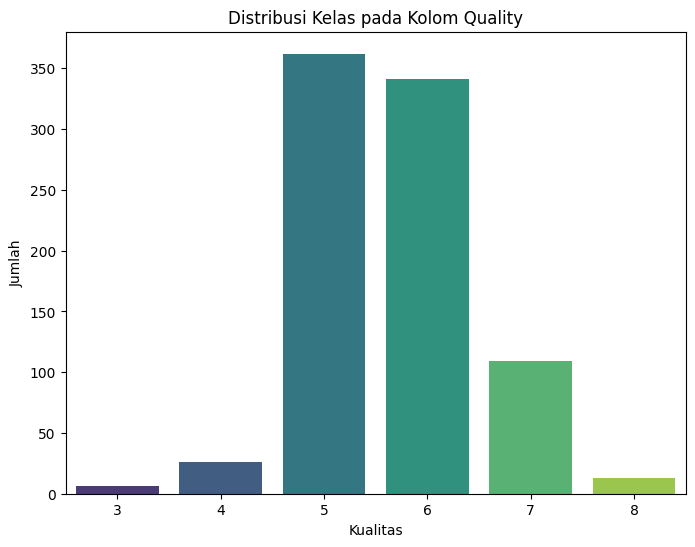

In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=train, palette='viridis')
plt.title('Distribusi Kelas pada Kolom Quality')
plt.xlabel('Kualitas')
plt.ylabel('Jumlah')
plt.show()

Dari chart tersebut, terlihat bahwa distribusi kualitas wine tidak seimbang (imbalanced) dengan kualitasnya terlalu terpusat pada 5 dan 6. Hal ini dikhawatirkan dapat menyebabkan model yang dibuat untuk prediksi nantinya akan cenderung mengalami bias pada kelas mayoritas dikarenakan kelas minoritas seperti 3,4, dan 8 memiliki terlalu sedikit data dibandingkan kualitas 5 dan 6.

### Split Fitur dan Target

In [6]:
X = train.drop(columns=['quality', 'Id'])
y = train['quality']

X_test_final = test.drop(columns=['Id'])

### Label Encoding

Encoding digunakan untuk mengubah label 3-8 menjadi 0-5

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### Train - Validation Split

Pada bagian ini, data dibagi menjadi 80% untuk training dan 20% untuk testing.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### Model Catboost

In [9]:
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

### Hyperparameter Tuning (Grid Search)

Hyperparameter tuning dilakukan menggunakan Grid Search untuk mencari hyperparameter terbaik untuk model catboost

In [ ]:
param_ = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'iterations': [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5, 7]
}

grid_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_cat.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_cat.best_params_)

Fitting 3 folds for each of 192 candidates, totalling 576 fits

Best Parameters:
{'depth': 6, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.1}


### Model Final

Setelah diperoleh Best Parameters, Best Parameters tersebut digunakan dan diinput secara manual pada model catboost

In [10]:
cat_final = CatBoostClassifier(
    depth=6,
    learning_rate=0.1,
    iterations=300,
    l2_leaf_reg=3,
    verbose=0,
    random_state=42
)

### Training Model

In [11]:
cat_final.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.1, random_state=42, verbose=0)

### Evaluasi Model

In [12]:
y_pred = cat_final.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.6395348837209303

Confusion Matrix:
 [[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 56 16  1  0]
 [ 0  0 18 44  6  0]
 [ 0  0  1 12  9  0]
 [ 0  0  0  1  1  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.70      0.77      0.73        73
           3       0.59      0.65      0.62        68
           4       0.53      0.41      0.46        22
           5       1.00      0.33      0.50         3

    accuracy                           0.64       172
   macro avg       0.47      0.36      0.39       172
weighted avg       0.62      0.64      0.62       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model klasifikasi menggunakan CatBoost menunjukkan kinerja yang cukup baik secara keseluruhan dengan nilai akurasi sebesar 64%. Hal ini mengindikasikan bahwa model mampu memprediksi sebagian besar data dengan benar, terutama pada kelas-kelas mayoritas. Namun, jika dilihat lebih dalam melalui confusion matrix dan classification report, performa model tidak merata pada seluruh kelas. Model menunjukkan kemampuan yang baik dalam mengklasifikasikan kelas tengah, khususnya pada kelas dengan jumlah data terbesar, yang ditunjukkan oleh nilai precision, recall, dan f1-score yang relatif tinggi. Sebaliknya, model gagal dalam mengidentifikasi kelas-kelas minoritas, yang terlihat dari nilai precision dan recall yang bernilai nol pada beberapa kelas dengan jumlah observasi yang sangat sedikit. Selain itu, pada kelas dengan nilai kualitas tinggi, model cenderung bersifat konservatif, yaitu hanya memprediksi kelas tersebut ketika sangat yakin, sehingga menghasilkan precision yang tinggi namun recall yang rendah. Secara keseluruhan, hasil ini menunjukkan bahwa model cenderung bias terhadap kelas mayoritas akibat ketidakseimbangan distribusi data, sehingga meskipun akurasi tergolong cukup baik, kemampuan model dalam membedakan seluruh kelas secara merata masih terbatas.

### Retrain Full Data

Melatih ulang model dengan seluruh data

In [13]:
cat_final.fit(X, y_encoded)

CatBoostClassifier(depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.1, random_state=42, verbose=0)

### Load Test Data

In [15]:
test = pd.read_csv('/content/data_testing (1).csv')
test = test.fillna(test.median(numeric_only=True))

X_test_final = test.drop(columns=['Id'])

### Prediksi

Pada bagian ini, dilakukan pelabelan pada data test dan kelas 3-8 yang tadinya diubah menjadi 0-5 di-invers lagi ke bentuk semula menjadi 3-8

In [16]:
test_pred_encoded = cat_final.predict(X_test_final)
test_pred = le.inverse_transform(test_pred_encoded)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Menyimpan Output

In [17]:
output = pd.DataFrame({
    'Id': test['Id'],
    'quality': test_pred
})

output.to_csv('submission_catboost_final.csv', index=False)
